[ Pytorch DL MODEL 실습 ]

- 데이터셋 : iris.csv
- 학습방법 : 지도학습 + 분류 ==> 2진분류


[1] 모듈로딩 <hr>

In [124]:
## 모듈로딩
import pandas as pd  # 데이터 모듈
import numpy as np

import torch         
# tensor 및 기본 함수 모듈   
import torch.nn as nn
# 인공신경망 관련 모듈
import torch.nn.functional as F
# 인공신경망 관련 함수
import torch.optim as optim
# 최적화 모듈

from sklearn.model_selection import train_test_split
# 학습용 데이터셋 관련 함수

In [125]:
irisDF = pd.DataFrame(pd.read_csv('../_data/iris.csv', engine='python'))

[2] 데이터 로딩 및 확인 <hr> 

In [126]:
irisDF.head()
irisDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [127]:
irisDF.variety.unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

In [128]:
irisDF.variety = irisDF.variety.replace({'Setosa':0, 'Versicolor':1, 'Virginica':2})

C:\Users\kdt\AppData\Local\Temp\ipykernel_5616\292886062.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  irisDF.variety = irisDF.variety.replace({'Setosa':0, 'Versicolor':1, 'Virginica':2})


In [129]:
irisDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [130]:
featureDF = irisDF[irisDF.columns[:-1]] # feature 4개
targetSR = irisDF[irisDF.columns[4]]  # 



In [131]:

X_train, X_test, y_train, y_test = train_test_split(
    featureDF, targetSR, train_size= 0.8, stratify=targetSR, random_state=42)

In [132]:
print(f"X_train => {X_train.ndim}D {X_train.shape} / X_test => {X_test.ndim}D, {X_test.shape}")
print(f"y_train => {y_train.ndim}D {y_train.shape}, / y_test => {y_test.ndim}D, {y_test.shape}")

X_train => 2D (120, 4) / X_test => 2D, (30, 4)
y_train => 1D (120,), / y_test => 1D, (30,)


[4] 모델 클래스 설계 및 구현 <hr>

In [133]:
""" 
데이터셋 iris: 피쳐 4, 타겟 1. 타겟은 범주형 3가지
학습 방법은 : 범주형이므로 분류 - 
구현알고리즘: 인공신경망 DNN
	  입력        퍼셉트론    활성화함수
입력층 4(피쳐4)   100(퍼셉트론)  RELU
은닉충  100         30 		RELU
출력층  30	    	3		SoftMax => 손실함수 내에 포함.

"""

class Iris_Model(nn.Module):
    # 인스턴스 초기화 및 생성 메서드
    def __init__(self):
        super().__init__() #부모(nn.Module)의 init 생성
        print('__init__()')
        self.in_layer=nn.Linear(4, 100)  #input, output
        self.hd_layer1=nn.Linear(100, 30)        # 히든1
        self.out_layer=nn.Linear(30, 3)

    # 순전파 학습 메서드 
    def forward(self, data):
        #- 입력층
        out=self.in_layer(data)      # data * weight + b
        out=F.relu(out)              # AF(data * weight + b) 결과물
                                     # 은닉으로 넘겨줌.
        #- 은닉층
        out=self.hd_layer1(out)      # out * weight + b
        out=F.relu(out)              # AF(out * weight + b) 결과물    
                
        #- 출력층 : 회귀로 결과 그라드 반환
        out=self.out_layer(out)      # out * weight + b

        return out
               

In [134]:
iModel = Iris_Model()
iModel

__init__()


Iris_Model(
  (in_layer): Linear(in_features=4, out_features=100, bias=True)
  (hd_layer1): Linear(in_features=100, out_features=30, bias=True)
  (out_layer): Linear(in_features=30, out_features=3, bias=True)
)

In [135]:
featureDF = irisDF[irisDF.columns[:-1]] # feature 4개
targetSR = irisDF[irisDF.columns[4]]  # 

featureTs = torch.FloatTensor(featureDF.values)
targetTs = torch.FloatTensor(targetSR)

X_train, X_test, y_train, y_test = train_test_split(
    featureTs, targetTs, train_size= 0.8, stratify=targetSR, random_state=42)


print(f"X_train => {X_train.ndim}D {X_train.shape} / X_test => {X_test.ndim}D, {X_test.shape}")
print(f"y_train => {y_train.ndim}D {y_train.shape}, / y_test => {y_test.ndim}D, {y_test.shape}")

X_train => 2D torch.Size([120, 4]) / X_test => 2D, torch.Size([30, 4])
y_train => 1D torch.Size([120]), / y_test => 1D, torch.Size([30])


In [136]:
data = torch.FloatTensor([[1. , 3.2, 1.9, 2.6]])

In [137]:

# 확률 변환 (Softmax 적용)
probabilities = torch.softmax(iModel(data), dim=1)

# 가장 높은 확률을 가진 클래스 선택
predicted_class = torch.argmax(probabilities, dim=1)

# 결과 출력
print(f"예측된 클래스: {predicted_class.item()}")

예측된 클래스: 1


[5] 학습 준비<hr>

In [138]:
## [5-1] 학습 관련 설정들
EPOCH = 1000                                         # 학습용 DS를 처음부터 끝까지 1번 학습하는 것을 에포크
BATCH_SIZE = 40                                      # DS를 학습량 만큼 나눈 사이즈
ITERATION = int(X_train.shape[0]/BATCH_SIZE)         # 학습용 DS이 분리된 수 => 1에포크에 W, b 업데이트 횟수
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"DEVICE : {DEVICE}, EPOCHS : {EPOCH}, BATCH_SIZE : {BATCH_SIZE} ITERATION: {ITERATION}")
      

DEVICE : cpu, EPOCHS : 1000, BATCH_SIZE : 40 ITERATION: 3


In [139]:
# [5-2] 학습 관련 인스턴스들
LR      = 0.0001                                # Learning Rate
MODEL  = Iris_Model()                           #학습 모델
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=LR)      #최적화 즉, 경사하강법 알고리즘으로 W, b의 값 개신
LOSS_FN = nn.CrossEntropyLoss()


__init__()


In [162]:
# 학습함수
def training():
    #학습 모드 설정
    MODEL.train()

    E_LOSS = 0
    for i in range(ITERATION):
        start = i*BATCH_SIZE
        end = start + BATCH_SIZE
        
        #nadrray ==> tensor 변환
        # 처음부터 텐서로 데이터 가르기를 하면 추가 변환이 필요없다.
        # x = torch.FloatTensor(X_train.values[start:end])
        # y = torch.FloatTensor(y_train.values[start:end])
        
        #가중치 기울기 0 초기화
        OPTIMIZER.zero_grad()
        
        #학습 진행
        # pre_y = MODEL(x)
        pre_y = MODEL(X_train)
        
        # 손실 계산
        # loss = LOSS_FN(pre_y, y.reshape(-1,1))
        loss = LOSS_FN(pre_y, y_train.reshape(-1).long())
        
        #역전파 진행
        loss.backward()
        
        #가중치/절편 업데이트
        OPTIMIZER.step()
        
        E_LOSS += loss.item()
        
    # print(f"[EPOCH = {epoch}], LOSS {E_LOSS/ITERATION}")
    return loss.item()

In [163]:
training()

0.0367896668612957

In [164]:
## 검증함수
## 검증용 데이터셋으로 모델 검증
## 학습 지속여부 결정 기준이 됨
## -----
def evaluate():
    # 에포크 단위로 검증 => 검증 모드
    MODEL.eval()
    
    # W, b가 업데이트 해제
    with torch.no_grad():
        # 검증용 데이터셋 => 텐서화
        # ndarray  ==> tensor 변환
        # x = torch.FloatTensor(X_test.values)
        # y = torch.FloatTensor(y_test.values)
        
        #검증진행
        # pre_y = MODEL(x)
        pre_y = MODEL(X_test)
        
        # 손실 계산
        # loss = LOSS_FN(pre_y, y.reshape(-1,1))
        loss = LOSS_FN(pre_y, y_test.reshape(-1).long())
        # 1차원 long 타입 요구.
        
        
    return loss.item()
        
        
        

In [165]:
evaluate()

0.04662492126226425

In [166]:
# 에포크 : DS 처음부터 ~ 끝까지 학습
LOSS_HIST = {'Train':[], 'Valid':[]}

#에포크 단위 학습/검증 진행
for epoch in range(EPOCH):
    trainLoss = training()
    validLoss = evaluate()
    
    LOSS_HIST['Train'].append(trainLoss)
    LOSS_HIST['Valid'].append(validLoss)
    
    print(f"\nEPOCH[{epoch}/{EPOCH}]-------------")
    print(f" - TRAIN_LOSS {trainLoss:.5f}")
    print(f" - VALID_LOSS {validLoss:.5f}")
    


EPOCH[0/1000]-------------
 - TRAIN_LOSS 0.03678
 - VALID_LOSS 0.04662

EPOCH[1/1000]-------------
 - TRAIN_LOSS 0.03678
 - VALID_LOSS 0.04662

EPOCH[2/1000]-------------
 - TRAIN_LOSS 0.03678
 - VALID_LOSS 0.04659

EPOCH[3/1000]-------------
 - TRAIN_LOSS 0.03677
 - VALID_LOSS 0.04665

EPOCH[4/1000]-------------
 - TRAIN_LOSS 0.03676
 - VALID_LOSS 0.04667

EPOCH[5/1000]-------------
 - TRAIN_LOSS 0.03676
 - VALID_LOSS 0.04667

EPOCH[6/1000]-------------
 - TRAIN_LOSS 0.03676
 - VALID_LOSS 0.04665

EPOCH[7/1000]-------------
 - TRAIN_LOSS 0.03675
 - VALID_LOSS 0.04661

EPOCH[8/1000]-------------
 - TRAIN_LOSS 0.03674
 - VALID_LOSS 0.04664

EPOCH[9/1000]-------------
 - TRAIN_LOSS 0.03674
 - VALID_LOSS 0.04666

EPOCH[10/1000]-------------
 - TRAIN_LOSS 0.03673
 - VALID_LOSS 0.04668

EPOCH[11/1000]-------------
 - TRAIN_LOSS 0.03673
 - VALID_LOSS 0.04668

EPOCH[12/1000]-------------
 - TRAIN_LOSS 0.03672
 - VALID_LOSS 0.04664

EPOCH[13/1000]-------------
 - TRAIN_LOSS 0.03671
 - VALID_L

In [167]:
len(LOSS_HIST['Train'])
len(LOSS_HIST['Valid'])

1000

In [168]:
LOSS_HIST['Valid']

[0.046617016196250916,
 0.046617284417152405,
 0.046589095145463943,
 0.046648744493722916,
 0.046670835465192795,
 0.04666780307888985,
 0.04664824903011322,
 0.04661283642053604,
 0.04663784056901932,
 0.04665930196642876,
 0.04667632281780243,
 0.04667748138308525,
 0.046640463173389435,
 0.04666534811258316,
 0.046662308275699615,
 0.04665226489305496,
 0.04663335904479027,
 0.04665200784802437,
 0.04668812453746796,
 0.04666750505566597,
 0.04666607454419136,
 0.046686749905347824,
 0.04670974239706993,
 0.04665333777666092,
 0.04668162018060684,
 0.04669959843158722,
 0.0466732494533062,
 0.04673080891370773,
 0.04676596447825432,
 0.04672566428780556,
 0.04666520282626152,
 0.04670894518494606,
 0.04673987254500389,
 0.046707477420568466,
 0.046686626970767975,
 0.04670815169811249,
 0.046724941581487656,
 0.04670620337128639,
 0.04678689315915108,
 0.046778980642557144,
 0.04675442725419998,
 0.046772655099630356,
 0.04675852507352829,
 0.046738144010305405,
 0.0466988757252693

In [169]:
LOSS_HIST['Train']

[0.036784183233976364,
 0.036780524998903275,
 0.03677530586719513,
 0.036768101155757904,
 0.0367630273103714,
 0.03675713390111923,
 0.036755017936229706,
 0.03674616664648056,
 0.036741551011800766,
 0.036735840141773224,
 0.03672991693019867,
 0.03672771155834198,
 0.03671935945749283,
 0.03671406954526901,
 0.036707449704408646,
 0.036703698337078094,
 0.036697424948215485,
 0.03669280186295509,
 0.036689162254333496,
 0.03668355196714401,
 0.036675695329904556,
 0.03667081147432327,
 0.03666781634092331,
 0.03666163235902786,
 0.03665704280138016,
 0.03665415942668915,
 0.03664451837539673,
 0.036644041538238525,
 0.03663913533091545,
 0.03663548454642296,
 0.036624349653720856,
 0.03662117198109627,
 0.0366143099963665,
 0.0366070494055748,
 0.036603864282369614,
 0.03659721091389656,
 0.036594364792108536,
 0.0365893691778183,
 0.03658321127295494,
 0.036580465734004974,
 0.03657115623354912,
 0.036566659808158875,
 0.0365617498755455,
 0.0365578718483448,
 0.0365540012717247,


In [170]:
# MODEL.eval()
xdata = range(1000)
ydata1 = LOSS_HIST['Train']
ydata2 = LOSS_HIST['Valid']
ydata = np.linspace(0,1,1000)

In [171]:
type(xdata), type(ydata1), type(ydata2)

(range, list, list)

In [172]:
import matplotlib.pyplot as plt

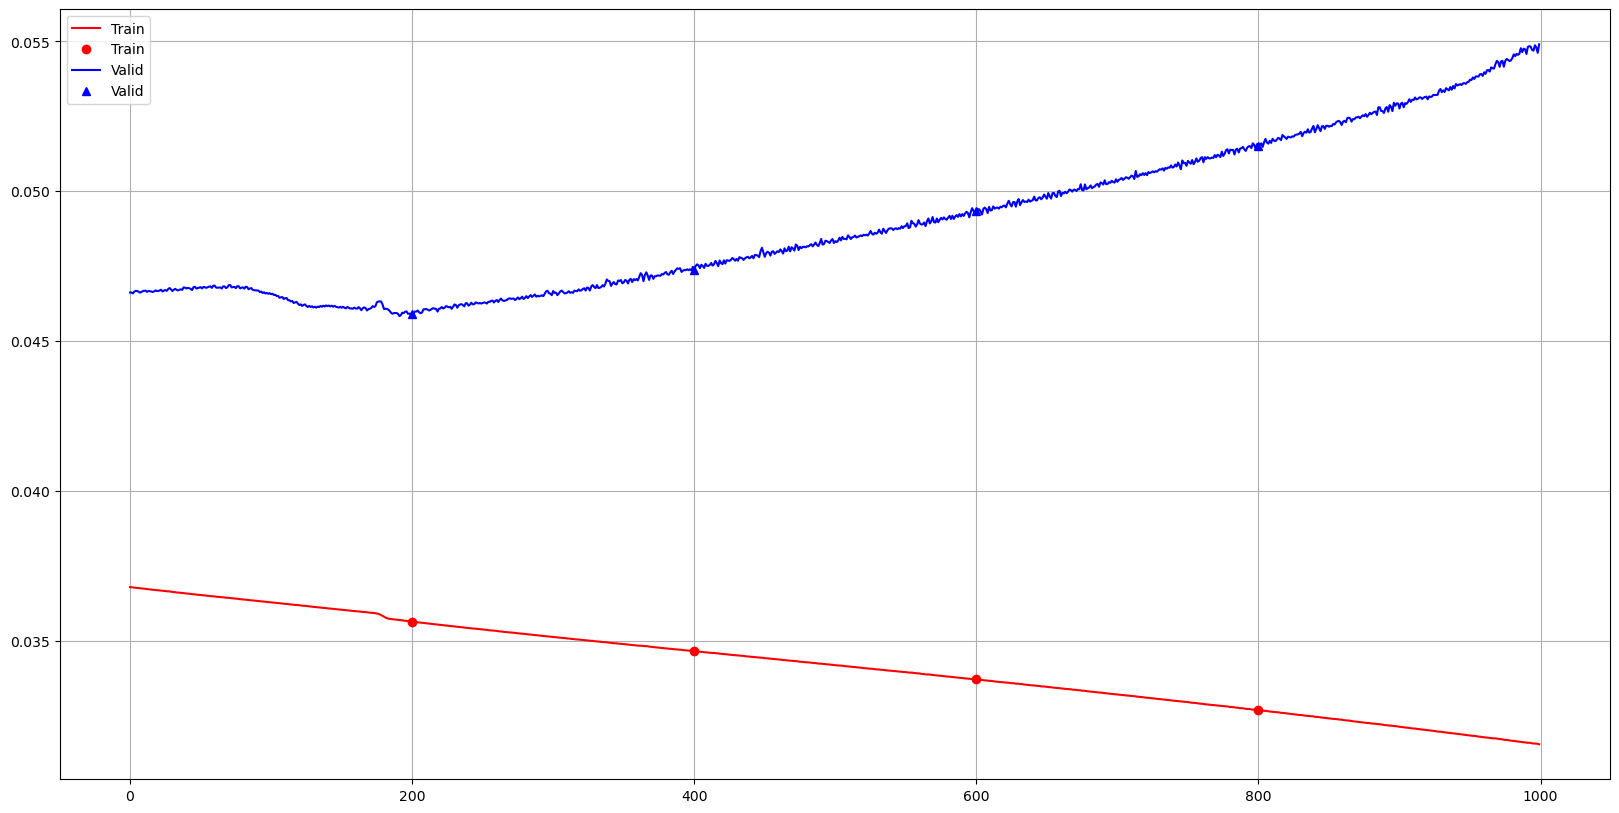

In [184]:
plt.figure(figsize=(20,10))
plt.plot(xdata, ydata1, 'r-', label ='Train')
plt.plot(xdata[200::200], ydata1[200::200], 'ro', label ='Train')
plt.plot(xdata, ydata2, 'b-', label ='Valid')
plt.plot(xdata[200::200], ydata2[200::200], 'b^', label ='Valid')

plt.legend()
plt.grid()
plt.show()